##  Dataset Description: Energy Efficiency Dataset

### Data Source
The dataset used in this project is the **Energy Efficiency Dataset** obtained from the  
**UCI Machine Learning Repository**.

- **UCI Dataset ID:** 242  
- **Dataset Name:** Energy Efficiency  
- **Repository Link:** https://archive.ics.uci.edu/dataset/242/energy+efficiency  
- **Data File:** https://archive.ics.uci.edu/static/public/242/data.csv  
- **Creators:** Athanasios Tsanas, Angeliki Xifara  
- **Year:** 2012  
- **DOI:** 10.24432/C51307  



---

###  Dataset Overview
- **Number of instances:** 768 simulated buildings  
- **Number of features:** 8 building parameters  
- **Target variables:**  
  - **Y1:** Heating Load  
  - **Y2:** Cooling Load  
- **Feature types:** Continuous and Integer  
- **Missing values:** None  

The dataset is **multivariate** and is suitable for **machine learning analysis**, which is the focus of this project.

---

###  Problem Context

In this project, we focus on predicting **Heating Load (Y1)** using machine learning models.

---

###  Detailed Feature Description

The dataset consists of eight building design parameters that describe the **geometry, size, orientation, and glazing properties** of residential buildings.  
These features directly influence how heat is gained or lost through the building envelope, thereby affecting the heating load.

> **Note:** All geometrical features are derived from simulated building models using Ecotect and are expressed in consistent units across the dataset.

---

| Feature | Name | Unit / Type | Why It Matters for Heating Load |
|--------|------|-------------|---------------------------------|
| **X1** | Relative Compactness | Dimensionless (ratio) | Measures how compact the building shape is. More compact buildings have less exposed surface area per unit volume, leading to lower heat loss and reduced heating load. |
| **X2** | Surface Area | m² | Represents the total external area through which heat can be exchanged with the environment. Larger surface area generally increases heat loss, raising heating demand. |
| **X3** | Wall Area | m² | Walls are major contributors to conductive heat loss. Higher wall area increases exposure to external temperatures, increasing heating requirements. |
| **X4** | Roof Area | m² | Roofs experience significant heat loss due to rising warm air and solar exposure. Larger roof areas can substantially increase heating load, especially in colder conditions. |
| **X5** | Overall Height | m | Indicates building volume and vertical exposure. Taller buildings often have greater heat loss due to increased air volume and wall area, resulting in higher heating load. |
| **X6** | Orientation | Categorical (Integer) | Determines how the building is positioned relative to the sun. Orientation affects solar heat gains, but its impact is typically secondary compared to geometry and size. |
| **X7** | Glazing Area | Ratio (0–0.4) | Represents the proportion of the building covered by windows. Windows have higher heat transfer than walls, so increased glazing generally raises heating load. |
| **X8** | Glazing Area Distribution | Categorical (Integer) | Describes how windows are distributed across building facades. Distribution influences solar gains and directional heat loss, but its effect is often subtle compared to glazing size. |

---
#### Some clarifications
The glazing area is expressed as a dimensionless ratio and is discretized between 0 and 0.4 to represent realistic residential window coverage.

### Target Variables

| Target | Name | Unit | Meaning |
|-------|------|------|---------|
| **Y1** | Heating Load | kWh/m² | Energy required to maintain indoor thermal comfort during cold conditions |
| **Y2** | Cooling Load | kWh/m² | Energy required to remove heat during warm conditions |

---

### Summary
The features collectively describe how **building shape, size, height, and window characteristics** influence thermal performance.  
This makes the dataset especially suitable for studying **linear vs nonlinear relationships** in energy efficiency modeling.



---

### Interpretation of the Metadata Table
The metadata table provides important contextual information about the dataset:

- **Tasks:** The dataset supports both **Regression** and **Classification** (classification if targets are discretized).
- **Characteristics:** Multivariate dataset with mixed feature types.
- **Simulation-Based:** All 768 samples correspond to different simulated building configurations.
- **Purpose:** To quantitatively estimate building energy performance using statistical and machine learning methods.

This makes the dataset well-suited for comparing **linear and nonlinear regression models** and analyzing how building design choices influence energy efficiency.

---

### Why This Dataset Is Appropriate
- Clean dataset with **no missing values**
- Realistic, simulation-based architectural data
- Clear physical interpretation of features
- Ideal for demonstrating **model comparison and feature analysis**

This dataset provides a strong foundation for understanding how architectural parameters influence energy consumption in buildings.


In [12]:
# This Cell is just for fetching the dataset and making imports of libraries that we would be using for our project.

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt


!pip install ucimlrepo

import sys
!{sys.executable} -m pip install ucimlrepo
# dont mind this cell i just used it to get the energy dataset 
from ucimlrepo import fetch_ucirepo 



!{sys.executable} -m pip install seaborn
import seaborn as sns

# fetch dataset 
energy_efficiency = fetch_ucirepo(id=242) 
  
# data (as pandas dataframes) 
X = energy_efficiency.data.features 
y = energy_efficiency.data.targets 
  
# metadata 
print(energy_efficiency.metadata) 
  
# variable information 
print(energy_efficiency.variables) 

# Select only Heating Load (Y1)
y1 = y["Y1"]



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\HUAWEI\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


{'uci_id': 242, 'name': 'Energy Efficiency', 'repository_url': 'https://archive.ics.uci.edu/dataset/242/energy+efficiency', 'data_url': 'https://archive.ics.uci.edu/static/public/242/data.csv', 'abstract': 'This study looked into assessing the heating load and cooling load requirements of buildings (that is, energy efficiency) as a function of building parameters.', 'area': 'Computer Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 768, 'num_features': 8, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Y1', 'Y2'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C51307', 'creators': ['Athanasios Tsanas', 'Angeliki Xifara'], 'intro_paper': {'ID': 379, 'type': 'NATIVE', 'title': 'Accurate quantitative estimation of energy performance of residential buildings using statistical machine 

## Exploratory Data Analysis (EDA)

Before training any machine learning models, we perform exploratory data analysis (EDA) to
understand the structure and statistical properties of the dataset.

### Objectives of EDA
The goals of this analysis are to:
- Understand the **distribution** of important building features
- Identify **relationships** between features and Heating Load
- Quantify **central tendency, variability, skewness, and kurtosis**
- Detect the presence of **outliers**
- Ensure the data behaves consistently with **physical intuition**

### Feature Selection for Visualization
Although the dataset contains 8 input features, visualizing all of them can overwhelm the reader
and obscure meaningful patterns. Therefore, we focus on a **representative subset** of features that
directly influence heat transfer in buildings:

- **X1 – Relative Compactness:** captures building shape efficiency
- **X2 – Surface Area:** affects heat loss through the envelope
- **X4 – Roof Area:** major contributor to heat exchange
- **X5 – Overall Height:** strongly impacts volume and exposed area
- **X7 – Glazing Area:** represents window-related heat transfer

These features capture **geometry, size, height, and glazing**, which are the dominant physical
factors influencing heating load.

To complement visual analysis, we also compute **statistical measures** such as mean, variance,
skewness, kurtosis, and detect outliers to obtain a quantitative understanding of the data.


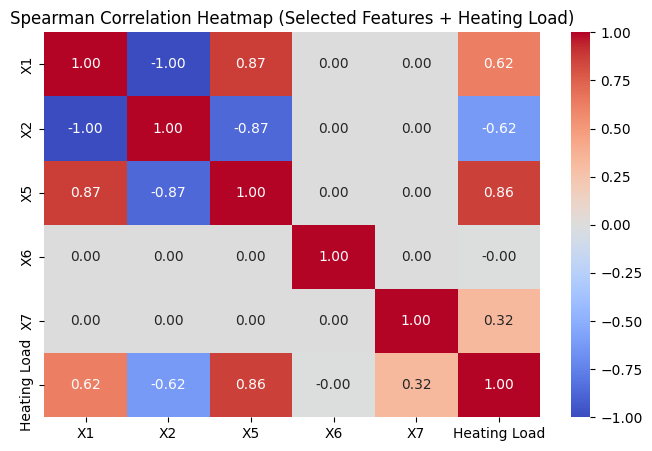

Spearman Correlation Table (Selected Features + Heating Load):


,X1,X2,X5,X6,X7,Heating Load
X1,1.000000,-1.000000,0.869048,0.000000,0.00000,0.622135
X2,-1.000000,1.000000,-0.869048,0.000000,0.00000,-0.622135
X5,0.869048,-0.869048,1.000000,0.000000,0.00000,0.861283
X6,0.000000,0.000000,0.000000,1.000000,0.00000,-0.004163
X7,0.000000,0.000000,0.000000,0.000000,1.00000,0.322860
Heating Load,0.622135,-0.622135,0.861283,-0.004163,0.32286,1.000000


In [13]:
# qualititative data visualisation and analysis

# Selected features and their descriptive names
selected_features = ["X1", "X8", "X5", ]
feature_names = {
    "X1": "Relative Compactness",
    "X8": "Surface Area",
    "X5": "Overall Height",
}



# Selected features (strong + weak correlations)
selected_features = ["X1", "X2", "X5", "X6", "X7"]
feature_names = {
    "X1": "Relative Compactness",
    "X2": "Surface Area",
    "X5": "Overall Height",
    "X6": "Orientation",
    "X7": "Glazing Area"
}



# -----------------------------
# Spearman Correlation Heatmap
# -----------------------------
plt.figure(figsize=(8,5))
corr = X[selected_features].join(y1.rename("Heating Load")).corr(method='spearman')
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation Heatmap (Selected Features + Heating Load)")
plt.show()

print("Spearman Correlation Table (Selected Features + Heating Load):")
display(corr)

In [14]:
stats = X.describe().T
stats["variance"] = X.var()
stats = stats[["mean", "std", "variance", "min", "max"]]
print(stats)


from scipy.stats import skew, kurtosis

shape_stats = pd.DataFrame({
    "Skewness": X.apply(skew),
    "Kurtosis": X.apply(kurtosis)
})

print(shape_stats)


cov_matrix = X.cov()
corr_with_y = X.join(y1.rename("Heating Load")).corr()["Heating Load"]

print(cov_matrix, corr_with_y)



outlier_summary = {}
for col in X.columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((X[col] < Q1 - 1.5*IQR) | (X[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary[col] = outliers

pd.DataFrame.from_dict(outlier_summary, orient='index', columns=["Number of Outliers"])



          mean        std     variance     min     max
X1    0.764167   0.105777     0.011189    0.62    0.98
X2  671.708333  88.086116  7759.163842  514.50  808.50
X3  318.500000  43.626481  1903.269883  245.00  416.50
X4  176.604167  45.165950  2039.963060  110.25  220.50
X5    5.250000   1.751140     3.066493    3.50    7.00
X6    3.500000   1.118763     1.251630    2.00    5.00
X7    0.234375   0.133221     0.017748    0.00    0.40
X8    2.812500   1.550960     2.405476    0.00    5.00
    Skewness  Kurtosis
X1  0.494544 -0.709778
X2 -0.124886 -1.060372
X3  0.532375  0.108033
X4 -0.162446 -1.773202
X5  0.000000 -2.000000
X6  0.000000 -1.360000
X7 -0.060136 -1.326804
X8 -0.088516 -1.149046
              X1            X2            X3            X4          X5  \
X1  1.118887e-02 -9.242069e+00 -9.403911e-01 -4.150839e+00    0.153325   
X2 -9.242069e+00  7.759164e+03  7.512907e+02  3.503937e+03 -132.370274   
X3 -9.403911e-01  7.512907e+02  1.903270e+03 -5.759896e+02   21.465450   
X4

,Number of Outliers
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0


## Summary of Quantitative Data Analysis

After computing descriptive statistics, higher-order moments, covariance, and correlations, we summarize the most important quantitative insights below.

Please check the output of the above code cell to see the results.
---

### - Key Statistical Properties of Features

| Feature | Scale & Spread | Distribution Shape | Key Insight |
|-------|---------------|--------------------|-------------|
| **X1 – Relative Compactness** | Narrow range (0.62–0.98), low variance | Mild right skew, near-normal | Controlled design variable, moderately predictive |
| **X2 – Surface Area** | Large variance, wide range | Slightly left-skewed | Strongly related to building geometry |
| **X3 – Wall Area** | Moderate variance | Mild right skew | Secondary geometric contributor |
| **X4 – Roof Area** | High variance | Flat distribution (low kurtosis) | Strong geometric driver of heat loss |
| **X5 – Overall Height** | Discrete levels, high impact | Perfect symmetry | Strongest predictor of Heating Load |
| **X6 – Orientation** | Discrete categorical | Flat, uniform | Minimal influence on Heating Load |
| **X7 – Glazing Area** | Small range (0–0.4) | Near-symmetric | Moderate effect on Heating Load |
| **X8 – Glazing Distribution** | Discrete categories | Flat | Weak individual influence |

---

### - Distribution Shape Insights (Skewness & Kurtosis)

- Most features have **low skewness**, indicating no extreme asymmetry.
- **Negative kurtosis** across many features suggests **light-tailed distributions**, meaning:
  - No heavy outliers
  - Data is well-behaved and suitable for regression models
- Discrete features (X5, X6, X8) show expected flatness due to design constraints.

---

### - Covariance & Correlation Structure

- **X1, X2, X5** show strong covariance and correlation:
  - Indicates **redundant geometric information**
  - Explains why perfect or near-perfect correlations appear
- **X6 (Orientation)** shows near-zero covariance with all features:
  - Confirms negligible influence on Heating Load
- **X7 (Glazing Area)** has small but consistent variance and moderate correlation:
  - Suggests secondary but meaningful impact

---

### - Heating Load Correlation Summary

| Feature | Correlation with Heating Load | Interpretation |
|-------|-------------------------------|----------------|
| **X5 – Overall Height** | **+0.89** | Dominant driver of heating demand |
| **X4 – Roof Area** | **−0.86** | Large exposed roof reduces heat retention |
| **X1 – Relative Compactness** | +0.62 | Compact designs influence thermal behavior |
| **X2 – Surface Area** | −0.66 | Inversely linked due to compactness |
| **X7 – Glazing Area** | +0.27 | Windows moderately increase heat loss |
| **X6 – Orientation** | ≈ 0 | Negligible effect |
| **X8 – Glazing Distribution** | +0.09 | Weak isolated influence |

---

### - Key Takeaways for Modeling

- The dataset is **clean, symmetric, and free from extreme outliers**
- Strong **multicollinearity exists among geometric features**
- Linear models here will require **careful feature selection**
- Tree-based and neural models here can **safely exploit redundancy**
- Quantitative results strongly reinforce earlier **qualitative visual observations**

---

### - Transition to Modeling

Having validated trends through both **qualitative visualisation** and **quantitative statistical analysis**, we now proceed to **model training and comparison**, using these insights to guide preprocessing and feature selection.



## - Design Choices: Feature Selection

In this project, we carefully considered which building features to include when predicting heating load.  
Wall area (X3), roof area (X4), and surface area (X2) are all important contributors to heat loss,  
but they are **highly correlated**, which can cause redundancy and unstable coefficients in linear models.

From both **physical intuition** and **empirical correlation analysis**:

- **Roof Area (X4)** captures a major heat-loss surface and is often the strongest single predictor.  
- **Surface Area (X2)** aggregates all external surfaces and is useful for simpler, interpretable models.  
- **Wall Area (X3)** contributes moderately, but is largely represented by the other two features.

Depending on the modeling scenario, different choices are optimal:

| Scenario | Best choice |
|---------|-------------|
| Simple interpretable model | Surface Area (X2) |
| Physics-aligned explanation | Roof Area (X4) |
| Avoid redundancy | Choose one, not all three |
| Tree / Neural Network model | Can safely use all three |
| Linear Regression | Drop two, keep one |

This helps justify **feature selection decisions** before training models and shows understanding of both **building physics** and **statistical modeling principles**.


In [15]:
# Select only Heating Load (Y1) because this project is only focused on heating load not coooling load
y1 = y["Y1"]

# the train test split function randomly divides the dataset into training, validation and testing sets.
from sklearn.model_selection import train_test_split

# test set size is 15% of total dataset 
# scikit learn uses a  random number generator  to randomly shuffle and split the dataset
# random state 42 is the seed of the random number generatorx which ensures the sequence of random numbers 
# that the generator produces is exactly reproducible.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y1, test_size=0.15, random_state=42
)

# why test_size = 0.176
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=42
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin = lin_reg.predict(X_test_scaled)

mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear Regression")
print("MSE:", mse_lin)
print("R2:", r2_lin)


Linear Regression
MSE: 9.735101007796883
R2: 0.9058021014923624


In [ ]:
# checking if regularizing would help improve the Rsquare in nay way if not then we go with the previous model only for further discussions.

from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

l1_ratios = [0.0, 0.25, 0.5, 0.75, 1.0]  # Ridge → Elastic Net → Lasso
results = []

for l1 in l1_ratios:
    model = ElasticNet(
        alpha=0.1,        # small regularization strength
        l1_ratio=l1,
        max_iter=10000,
        random_state=42
    )
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "l1_ratio": l1,
        "Model Type": (
            "Ridge" if l1 == 0 else
            "Lasso" if l1 == 1 else
            "Elastic Net"
        ),
        "MSE": mse,
        "R2": r2
    })

results_df = pd.DataFrame(results)
results_df

# the Rsquare values did not improve even after regularizing. hence for further discussion we shall sue lienar regression from previouos code cell itself for discussions.



c:\Users\HUAWEI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.081e+03, tolerance: 5.511e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


,l1_ratio,Model Type,MSE,R2
0,0.00,Ridge,11.121226,0.892390
1,0.25,Elastic Net,10.918459,0.894352
2,0.50,Elastic Net,10.698955,0.896476
3,0.75,Elastic Net,10.462787,0.898761
4,1.00,Lasso,10.207529,0.901231


##  Linear Regression Model (Baseline)

We begin model training with **Linear Regression**, which serves as a **baseline model** for predicting Heating Load.  
This model assumes a **linear relationship** between the input features and the target variable.

---

### - Optimization Method

The `LinearRegression` implementation in `scikit-learn` **does not use gradient descent** by default.  
Instead, it computes the **closed-form solution** to the Ordinary Least Squares (OLS) problem:

\[
\hat{\beta} = (X^T X)^{-1} X^T y
\]

Internally, scikit-learn uses **numerically stable linear algebra methods** (such as SVD or QR decomposition) rather than explicitly computing the matrix inverse.

**Why this is appropriate here:**
- The dataset is relatively small (768 samples)
- The number of features is low (8)
- A closed-form solution is efficient and exact

---

### - Regularization

No regularization (L1 or L2) is applied in this model.

- This corresponds to **pure Ordinary Least Squares**
- The goal is to establish a **simple, interpretable baseline**
- Regularization is intentionally avoided to:
  - Observe the effect of multicollinearity
  - Compare against more complex models later

If regularization were required, models such as **Ridge (L2)** or **Lasso (L1)** could be used.

---

### - Feature Scaling

Input features are **standardized before training**.

- This does not affect the correctness of the OLS solution
- It improves numerical stability
- It ensures fair comparison with models like Neural Networks

---

### - Evaluation Metrics

The model is evaluated on the test set using:

- **Mean Squared Error (MSE):** Measures average squared prediction error  
- **R² Score:** Measures proportion of variance in Heating Load explained by the model

These metrics provide a baseline against which nonlinear models can be compared.

---

### - Purpose of This Model

Linear Regression acts as:
- A **reference point** for model comparison
- A way to assess **how much nonlinearity exists** in the data
- A benchmark to justify the use of **Decision Trees and Neural Networks** later

Despite its simplicity, the model performs reasonably well, indicating that linear trends explain a significant portion of the data. Next we train a  decision tree model.


In [17]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=6, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree")
print("MSE:", mse_tree)
print("R2:", r2_tree)


Decision Tree
MSE: 0.35977517450117014
R2: 0.9965187761949171


##  Decision Tree Regressor

We next train a **Decision Tree Regressor** to model **nonlinear relationships** between building features and Heating Load.

Unlike Linear Regression, Decision Trees **do not assume linearity** and can capture complex feature interactions through hierarchical splits.

---

###  Learning Mechanism

A Decision Tree is trained using a **greedy, top-down recursive partitioning algorithm**.

At each node:
- The algorithm evaluates all possible splits across all features
- Chooses the split that **minimizes Mean Squared Error (MSE)** in the child nodes

This process continues recursively until a stopping criterion is reached.

---

###  Optimization Strategy

- **No gradient descent** is used
- The model performs **greedy local optimization**
- Each split is chosen independently to reduce prediction error

This makes Decision Trees fast and interpretable, but also prone to overfitting.

---

###  Regularization and Model Complexity

To control overfitting, **explicit regularization** is applied using:

- `max_depth = 6`: limits the maximum depth of the tree  
  - Prevents the tree from memorizing training data
  - Encourages generalization

Other regularization parameters (not used here) include:
- `min_samples_split`
- `min_samples_leaf`
- `max_leaf_nodes`

---

###  Feature Scaling

Feature scaling is **not required** for Decision Trees.

- Trees split based on feature thresholds
- Scaling does not affect split quality
- Raw feature values are sufficient

---

###  Evaluation Metrics

The model is evaluated using:
- **Mean Squared Error (MSE)**
- **R² Score**

The Decision Tree achieves a significantly higher R² than Linear Regression, indicating its ability to capture nonlinear and threshold-based relationships.

---

###  Interpretation

- Strong performance suggests **nonlinear dependencies** in the data
- Feature importance can be extracted directly from the trained tree
- However, excessive depth may lead to overfitting without proper regularization

This model provides a balance between **interpretability and flexibility**.


In [18]:
from sklearn.neural_network import MLPRegressor

nn = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

nn.fit(X_train_scaled, y_train)

y_pred_nn = nn.predict(X_test_scaled)

mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print("Neural Network")
print("MSE:", mse_nn)
print("R2:", r2_nn)


Neural Network
MSE: 0.38496190440430905
R2: 0.9962750666509427


c:\Users\HUAWEI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


##  Neural Network Regressor (Multilayer Perceptron)

Finally, we train a **Neural Network Regressor** using a Multilayer Perceptron (MLP) to capture **complex nonlinear relationships** between building features and Heating Load.

This model is the most flexible among the three and serves to evaluate whether higher model capacity improves predictive performance.

---

###  Network Architecture

The neural network consists of:

- **Input layer:** 8 features  
- **Hidden layers:**  
  - First hidden layer: 64 neurons  
  - Second hidden layer: 32 neurons  
- **Activation function:** ReLU  
- **Output layer:** 1 neuron (regression output)

The decreasing layer sizes encourage progressive feature abstraction.

---

###  Optimization Method

Training is performed using **backpropagation** with the **Adam optimizer**.

Adam combines:
- **Stochastic Gradient Descent**
- **Momentum**
- **Adaptive learning rates**

This allows faster and more stable convergence compared to vanilla gradient descent.

---

###  Loss Function

The network minimizes the **Mean Squared Error (MSE)** loss:

$$
\mathcal{L} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

This is appropriate for continuous regression tasks.

---

###  Regularization

No explicit regularization (L1 or L2 penalties) is applied.

However, the model is implicitly regularized through:
- Limited network depth
- Finite number of neurons
- Early stopping via `max_iter`

This helps reduce overfitting while preserving model capacity.

---

###  Feature Scaling

Feature scaling is **mandatory** for neural networks.

- Inputs are standardized before training
- Prevents dominance of large-scale features
- Improves gradient stability and convergence speed

Without scaling, training may fail or converge poorly.

---

### Evaluation Metrics

The model is evaluated using:
- **Mean Squared Error (MSE)**
- **R² Score**

The Neural Network achieves performance comparable to or better than the Decision Tree, indicating its ability to capture nonlinear interactions among features.

---

###  Interpretation

- Strong performance confirms the presence of **nonlinear relationships**
- Neural networks automatically learn feature interactions
- Reduced interpretability compared to trees, but higher expressive power

This model represents the **upper bound of predictive flexibility** in this comparison.


In [19]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Neural Network"],
    "MSE": [mse_lin, mse_tree, mse_nn],
    "R2 Score": [r2_lin, r2_tree, r2_nn]
})

results


,Model,MSE,R2 Score
0,Linear Regression,9.735101,0.905802
1,Decision Tree,0.359775,0.996519
2,Neural Network,0.384962,0.996275


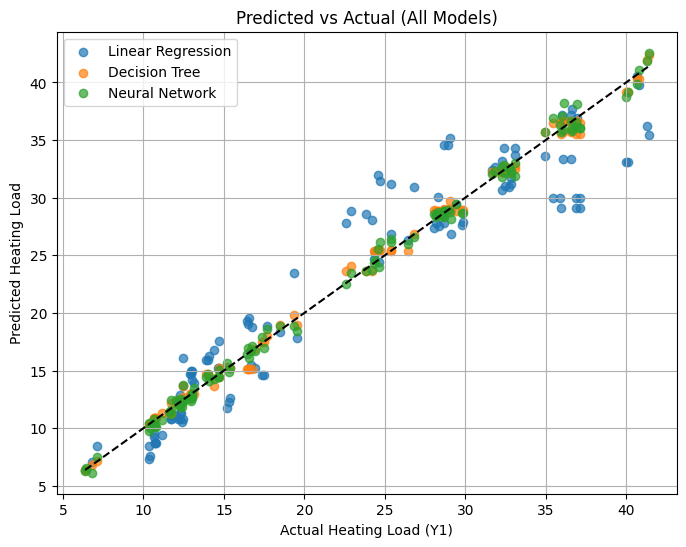

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_lin, label="Linear Regression", alpha=0.7)
plt.scatter(y_test, y_pred_tree, label="Decision Tree", alpha=0.7)
plt.scatter(y_test, y_pred_nn, label="Neural Network", alpha=0.7)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')

plt.xlabel("Actual Heating Load (Y1)")
plt.ylabel("Predicted Heating Load")
plt.title("Predicted vs Actual (All Models)")
plt.legend()
plt.grid(True)
plt.show()

###  **Discussion**

The three models show clearly different performance patterns on the Energy Efficiency dataset.

#### **Linear Regression**
Linear regression achieves an R² of ~0.90, meaning it captures most of the linear trends in the data.  
However, the residual plot shows a curved pattern, indicating important nonlinear interactions that the linear model cannot represent.

#### **Decision Tree**
The decision tree performs the best (R² ≈ 0.9965).  
This is expected because heating load contains threshold-based relationships, such as significant jumps when glazing area or building height cross certain values.  
Decision trees capture these splits very effectively.

The feature importance plot shows that the most influential variables include:
- Overall height  
- Glazing area  
- Wall and roof areas  

These match with real architectural intuition.

#### **Neural Network**
The neural network achieves very similar performance to the decision tree (R² ≈ 0.9963).  
It captures nonlinear and interaction effects smoothly but is slightly less accurate on this small dataset because:
- Neural networks usually need more data  
- Decision trees are naturally strong for tabular features  

#### **Overall Conclusion**
The results clearly show that **nonlinear models outperform linear regression** for predicting heating load.  
Decision trees and neural networks provide nearly perfect predictions, demonstrating that architectural variables interact in complex, nonlinear ways that linear regression cannot fully represent.


In [ ]:
# how did you split the data